In [1]:
import biodivine_aeon as ba
from copy import copy

# Colors for visualizations:
colors = {
    "blue": "#1f77b4",
    "orange": "#ff7f0e",
    "green": "#2ca02c",
    "red": "#d62728",
    "purple": "#9467bd",
    "brown": "#8c564b",
    "pink": "#e377c2",
    "gray": "#7f7f7f",
    "olive": "#bcbd22",
    "cyan": "#17becf",
}

## Part I: Boolean Networks Basics

The following code compiles a simple three-node BN representing a double-negative feedback loop between genes X and Y, which are controlled by gene S. The set of regulations and the update functions representing the logic rules for all the nodes are specified in the AEON tool native text format. Note that the node S has no incoming regulations. It's logic rule is set to the constant <code>True</code> (meaning it is permanently activated/expressed).

The <code>to_graph().show()</code> method is used to generate the regulatory graph.

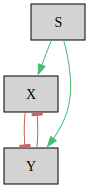

In [63]:
bn = ba.BooleanNetwork.from_aeon("""

    # Influences; "->" is positive, "-|" is negative

    S -> X
    S -> Y

    X -| Y
    Y -| X

    # Update logic:

    $S:True
    $X:S & !Y
    $Y:S & !X

""")

bn.to_graph().show()

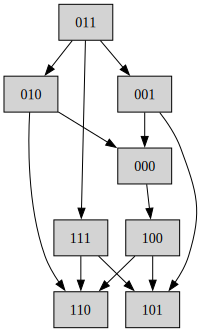

In [75]:
# Asynchronous semantics is employed to generate the state transition graph (STG) of the BN specified above. 
# The binary code in every state denotes the bit vector showing the value of all BN nodes in the particular state.
#     In this case, 110 denotes the state where S==1, X==1, Y==0 (following the order of update rules list above).

stg = ba.AsynchronousGraph(bn)
stg.show()

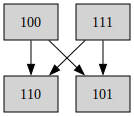

In [72]:
# Because the graphs can be large, we can also restrict the visualisation to a particular subset of vertices. 
# In this case, we focus on a subgraph of the STG showing only states where the gene S is active (has the value "1"). 

stg.show(subgraph = stg.mk_subspace({ "S": 1 }))

In [76]:
# The states 110 and 101 have no outgoing transitions. The dynamical system is going to reside in one of them in the long term. 
# These states represent trivial terminal components of the STG (single-state attractors). We call them fixed points.

# We can directly find fixed points (single-state attractors) without browsing the STG manually. 
# Notice that the statement returns exactly the two terminal states.

fixed_points = ba.FixedPoints.symbolic(stg)

print("Model fixed points:")
for state in fixed_points.vertices():
    print("\t -", state)

Model fixed points:
	 - VertexModel({'S': 1, 'X': 0, 'Y': 1})
	 - VertexModel({'S': 1, 'X': 1, 'Y': 0})


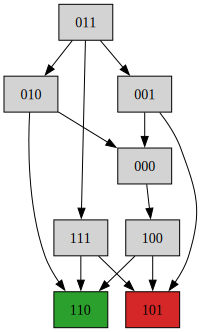

In [79]:
# When mapping the BN to a relevant biological interpretation -- phenotypes, the genes X and Y can be interpreted as marker genes (each marking a certain phenotype, here a particular cell fate).
# The two fixed points differ in the marker gene expressed. 

PHENOTYPES = {
    'cell_fate_I'   : { 'S': 1, 'X': 1, 'Y': 0 },
    'cell_fate_II'  : { 'S': 1, 'X': 0, 'Y': 1 },
}

# Finally, we can use the highlight feature to assign distinct colours to the two phenotype states defined above.

stg.show(
     highlight=[
        (colors['green'], PHENOTYPES['cell_fate_I']),
        (colors['red'], PHENOTYPES['cell_fate_II']),
    ],   
)

## Exercise:

1. How would the systems dynamics change if the rule of S were changed to a constant <code>False</code>?

2. Change both negative regulations in the BN above to positive regulations and update the logic rules appropriately. How does the STG change? 

3. Change regulations between X and Y in such a way that one of them is negative and the other one positive. How do the attractors change? 

## Part II: Working with Boolean Networks -- Cortical Area Development Model

In this tutorial, we will be working with a small Boolean model ([BBM-007](https://bbm.sybila.fi.muni.cz/models/7)) of cortical area development introduced in 2010 by Giacomantonio and Goodhill. The model itself is quite simple, but should be sufficient for demonstration purposes.

```
Giacomantonio, Clare E., and Geoffrey J. Goodhill. "A Boolean model of the gene regulatory network underlying Mammalian cortical area development." PLoS computational biology 6.9 (2010): e1000936.
```

The model consists of five genes:

 - `NR2F1`: https://www.genecards.org/card/NR2F1 (previously known as COUP-TF1)
 - `SP8`: https://www.genecards.org/card/SP8
 - `EMX2`: https://www.genecards.org/card/EMX2
 - `FGF8`: https://www.genecards.org/card/FGF8
 - `PAX6`: https://www.genecards.org/card/PAX6

These are all known transcription factors connected to tissue development. 

When the model was constructed, the regulations were based on results published in the literature. However, only the `SP8 -> FGF8` regulation was confirmed as a direct regulatory mechanism. The remaining influences were observed, but it was not clear whether they acted directly, or transitively through some other genes.


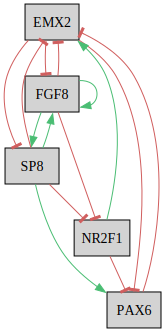

In [84]:
bn = ba.BooleanNetwork.from_aeon("""

    # Influences; "->" is positive, "-|" is negative

    SP8 -| EMX2
    NR2F1 -> EMX2
    PAX6 -| EMX2
    FGF8 -| EMX2
    EMX2 -| SP8
    FGF8 -> SP8
    SP8 -| NR2F1
    FGF8 -| NR2F1
    SP8 -> PAX6
    NR2F1 -| PAX6
    EMX2 -| PAX6
    SP8 -> FGF8
    EMX2 -| FGF8
    FGF8 -> FGF8

    # Update logic:

    $NR2F1: !FGF8 & !SP8
    $EMX2: NR2F1 & !FGF8 & !SP8 & !PAX6
    $FGF8: FGF8 & SP8 & !EMX2
    $PAX6: SP8 & !EMX2 & !NR2F1
    $SP8: FGF8 & !EMX2

""")

bn.to_graph().show()

The purpose of the model is to establish the relationships driving the differentiation between anterior (front) and posterior (back) parts of the developing neural cortex. *The model assumes the development starts by activation of `FGF8` in the anterior cortex* through a mechanism that is external to the model (i.e., we don't know what kickstarts the `FGF8` expression). Once `FGF8` is expressed in the anterior cortex, it is followed by `PAX6` and `SP8`. Meanwhile, in the posterior cortex, the absence of `FGF8` leads to the expression of `EMX2` and `NR2F1`.

![Figure by Giacomantonio and Goodhill showing activity across anterior and posterior regions.](anterior-posterior.png)

Based on this prior knowledge, we can establish four "phenotypes": `anterior-early`, `anterior-late`, `posterior-early` and `posterior-late`.

In the context of our model, the `late` phenotypes are "stable" (they cannot be escaped once reached), while the `early` phenotypes are "transient" (they will eventually be escaped towards one of the stable phenotypes). For now, we will just declare each phenotype as a Python dictionary and we will use them later when actually inspecting the behavior of our model.

In [85]:
PHENOTYPES = {
    'anterior-late'   : { 'EMX2': 0, 'FGF8': 1, 'NR2F1': 0, 'PAX6': 1, 'SP8': 1 },
    'posterior-late'  : { 'EMX2': 1, 'FGF8': 0, 'NR2F1': 1, 'PAX6': 0, 'SP8': 0 },
    'anterior-early'  : { 'EMX2': 0, 'FGF8': 1, 'NR2F1': 0, 'PAX6': 0, 'SP8': 0 },    
    'posterior-early' : { 'EMX2': 0, 'FGF8': 0, 'NR2F1': 0, 'PAX6': 0, 'SP8': 0 },   
}

## Integrity constraints of Boolean networks

An important aspect of BN modeling is that in general, our network can consist of any update functions. However, different functions can lead to vastly different outcomes. As such, we want to "restrict" the space of possible functions as much as possible based on what we know about the underlying biology of our system. In the original paper, the authors of our model explicitly state that they combine all regulators using `AND` (`&`), and negate (`!`) the input from inhibitors, because this is the simplest, most natural option.

In general, if we have a known regulatory graph with exact interactions and prescribed positive/negative influences, it limits the space of possible update functions significantly. Some fraction of the update functions will "agree" with our regulatory graph, while other functions may not be valid.

In a Boolean network with a known regulatory graph, we thus typically expect the following to hold:

 - The update function `f_X` of `X` can only depend on `Y` if `X` is regulated by `Y` (i.e., `Y -> X` or `Y -| X`).
 - Symmetrically, if `X` is regulared by `Y`, then the update function of `X` should actually depend on `Y` (this is called input *essentiality*).
 - If `X` is postively regulated by `Y` (i.e., `Y -> X`), then the update function `f_X` must be positively monotone in `Y`. This means that for any input, if we increase `Y`, the output of `f_X` can only increase, it cannot go down.
 - Symmetrically, increasing the value of an inhibitor (i.e., `Y -| X`), we expect that the output of `f_X` can only go down, never up.

For simple networks, it is easy to check that these rules hold "by hand". However, for complicated functions, it is not easy to verify and indeed, some models in the literature can contain such subtle errors. As such, we should always make sure these integrity constraints are satisfied.

In [128]:
bn_example = copy(bn)

In [129]:
# Presence of unknown regulators is already checked while parsing the update function,
# because it is the simplest part:

try:
    bn_example.set_update_function("SP8", "FGF8 & !EMX2 & PAX6")
except Exception as e:
    print(f"Error: {e}.")

Error: Variable 'SP8' is regulated by ["EMX2", "FGF8"], but ["EMX2", "FGF8", "PAX6"] were found as arguments.


In [130]:
# Essentiality and monotonicity can be harder to check. As such, we delegate this
# to special functions instead of doing it on the fly whenever the function changes:

# Here, `SP8` depends on `FGF8`, but the function does not actually use it.
bn_example.set_update_function("SP8", "!EMX2")
print("Integrity check (1):", bn_example.check_regulation_constraints())

# Also, you can't just fool the check by writing a function where some `FGF8` symbol
# is present, but is not really contributing anything to the output:

bn_example.set_update_function("SP8", "!EMX2 & (FGF8 | !FGF8)")
print("Integrity check (2):", bn_example.check_regulation_constraints())

Integrity check (1): ['Regulator `FGF8` is not essential in the update function of `SP8`']
Integrity check (2): ['Regulator `FGF8` is not essential in the update function of `SP8`']


In [131]:
# Similarly, we can detect broken monotonicity. Here, we have negated both inputs
# compared to the original function, meaning their monotonicity is now switched:

bn_example.set_update_function("SP8", "EMX2 & !FGF8")
print("Integrity check (3):", bn_example.check_regulation_constraints())

Integrity check (3): ['Regulator `EMX2` is not negatively monotone (inhibitor) in the update function of `SP8`', 'Regulator `FGF8` is not positively monotone (activator) in the update function of `SP8`']


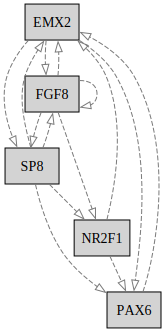

In [133]:
# It is important to note that in the current state, the update logic of `SP8` does not respect the regulation graph 
# (given at the beginning of this part).

# If you absolutely must work with the BN in its current form, you can always
# ignore the regulation constraints (this will also show up in our visualisation):

bn_example.remove_regulation_constraints().to_graph().show()

Integrity check (4): []


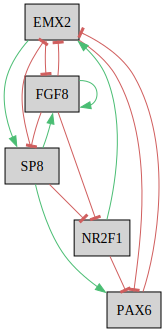

In [135]:
# Alternatively, you can also "infer" the most likely regulation graph from an
# existing BN (a set of update functions). Note that compared to the original BN given at the beginning, the monotonicity
# of the `SP8` regulators is switched here.

bn_repaired = bn_example.infer_valid_graph()
print("Integrity check (4):", bn_repaired.check_regulation_constraints())
bn_repaired.to_graph().show()

## State space, fixed-points and basins

Now that we are sure that our Boolean model satisfies all major regulation constraints proposed by the original study, we can actually look at the predictions of our Boolean model. For this, we will use the *state-transition graph* (STG). Here, we are using the *asynchronous* state update (each edge updates exactly one variable, multiple outgoing edges are possible if multiple variables can change value); if there is time, we can discuss why and what other updates are possible when using Boolean models.

In this tutorial, we will be actually showing visualizations of the state transition graph, because it is still reasonably small. However, for a more realistic Boolean network, the STG can contain billions of nodes and cannot be easily visualized. As such, most methods manipulate the graph vertices in some abstract or symbolic manner through sets, not by directly traversing the graph.

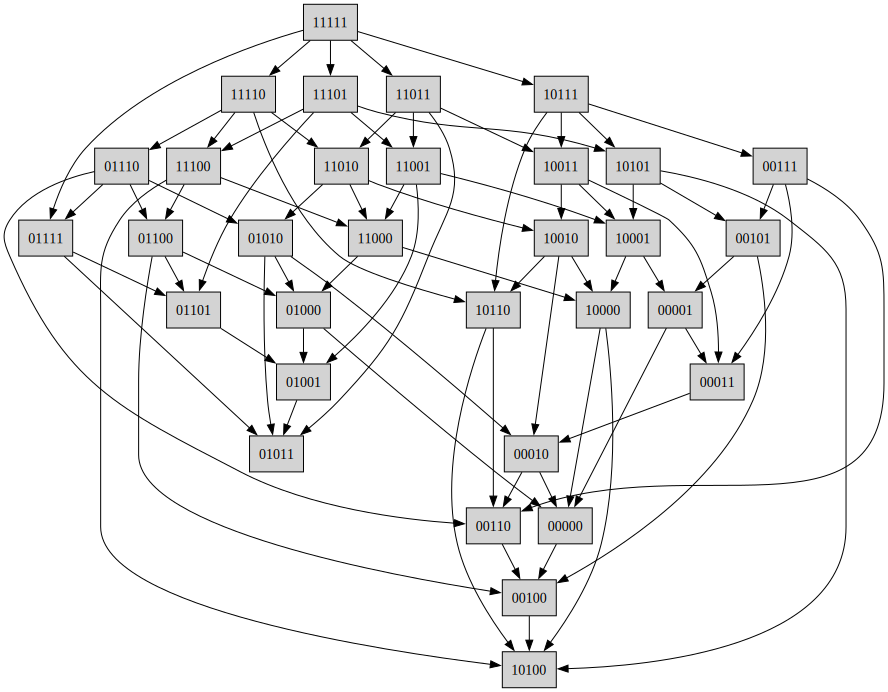

In [138]:
# We can visualise the STG the same way we visualised the regulatory graph.

stg = ba.AsynchronousGraph(bn)
stg.show()

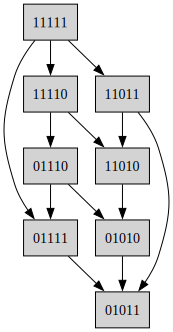

In [144]:
# Because the graphs can be large, we can also restrict the visualisation to a particular subset of vertices.
# By adding `prune_outgoing_edges`, we are saying that any edge leaving the given subgraph should not be shown,
# which further simplifies the diagram (but we have to keep in mind that there can be other outgoing edges that
# lead outside of the shown portion of the graph).

stg.show(subgraph = stg.mk_subspace({ "FGF8": 1, "PAX6": 1 }), prune_outgoing_edges = True)

# You can remove the prune_outgoing_edges option from the command above (or changed it to False) and compare the obtained graphs.

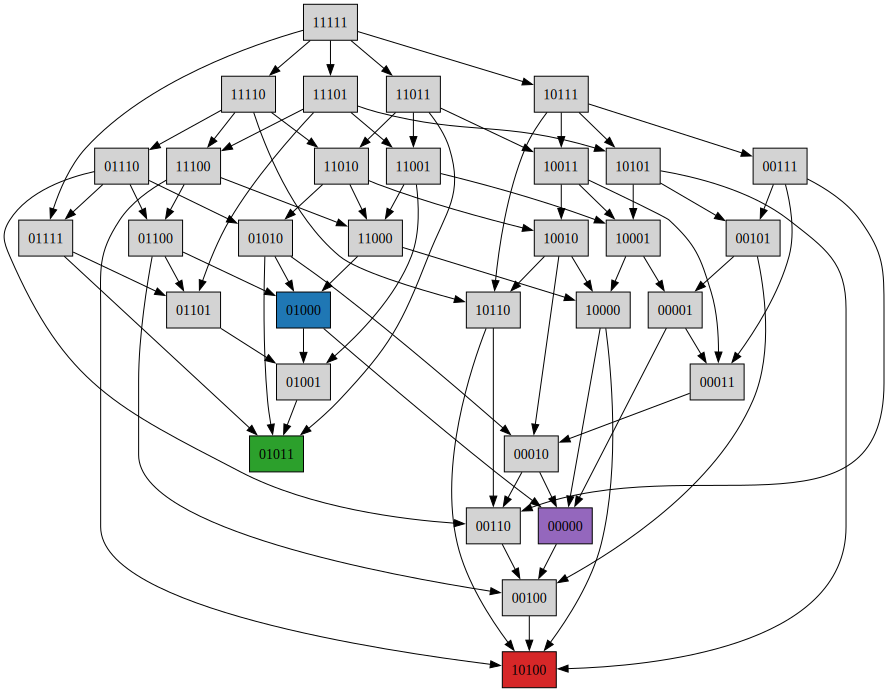

In [145]:
# Finally, we can use the highlight feature to assign colors to specific vertices (or sets of vertices).
# If one vertex appears in multiple sets, it is drawn with the last applicable color.

stg.show(
     highlight=[
        (colors['green'], PHENOTYPES['anterior-late']),
        (colors['red'], PHENOTYPES['posterior-late']),
        (colors['blue'], PHENOTYPES['anterior-early']),
        (colors['purple'], PHENOTYPES['posterior-early']),
    ],   
)

In the highlighted graph above, we can notice that our terminal phenotypes indeed correspond to *fixed points*.

As we discussed, because the STG can often be very large, we can't simply find fixed points by going through the states one by one. Instead, there are more sophisticated algorithms for finding all fixed points of a Boolean network.

In [15]:
# We can run such method. Notice that it returns exactly the two terminal phenotypes
# that we highlighted in the STG visualization above:

fixed_points = ba.FixedPoints.symbolic(stg)

print("Model fixed points:")
for state in fixed_points.vertices():
    print("\t -", state)

Model fixed points:
	 - VertexModel({'EMX2': 0, 'FGF8': 1, 'NR2F1': 0, 'PAX6': 1, 'SP8': 1})
	 - VertexModel({'EMX2': 1, 'FGF8': 0, 'NR2F1': 1, 'PAX6': 0, 'SP8': 0})


Another important feature of a Boolean network connected to fixed points are *basins*. A basin consists of all states from which we can eventually reach a particular fixed point (or a set of fixed points).

Because each state can have multiple successors (and can therefore reach multiple fixed points), we often distinguish between a *weak basin* of a fixed point `F` (we can reach the fixed point `F` via *some* path) and *strong basin* (we always reach the fixed point `F` via *all* paths).

In our case, we could again derive the basins of each fixed point simply by looking at the graph itself, but as with fixed points, there are more sophisticated algorithms that also work for much larger graphs:

In [150]:
# First, we convert the phenotype descriptions into vertex sets (in this case containing
# a single state; the phenotype).
posterior_late = stg.mk_subspace(PHENOTYPES['posterior-late'])
print("Posterior terminal phenotype:", posterior_late.cardinality())

anterior_late = stg.mk_subspace(PHENOTYPES['anterior-late'])
print("Anterior terminal phenotype:", anterior_late.cardinality())

# Next, find all states from which we can reach `posterior_late`.
posterior_weak_basin = ba.Reachability.backward_superset(stg, posterior_late)
# And finally, remove all states from which we can reach something else that cannot reach `posterior_late`.
posterior_strong_basin = ba.Reachability.forward_subset(stg, posterior_weak_basin)
print("Posterior weak basin:", posterior_weak_basin.cardinality())
print("Posterior strong basin:", posterior_strong_basin.cardinality())

anterior_weak_basin = ba.Reachability.backward_superset(stg, anterior_late)
anterior_strong_basin = ba.Reachability.forward_subset(stg, anterior_weak_basin)
print("Anterior weak basin:", anterior_weak_basin.cardinality())
print("Anterior strong basin:", anterior_strong_basin.cardinality())

Posterior terminal phenotype: 1
Anterior terminal phenotype: 1
Posterior weak basin: 28
Posterior strong basin: 16
Anterior weak basin: 16
Anterior strong basin: 4


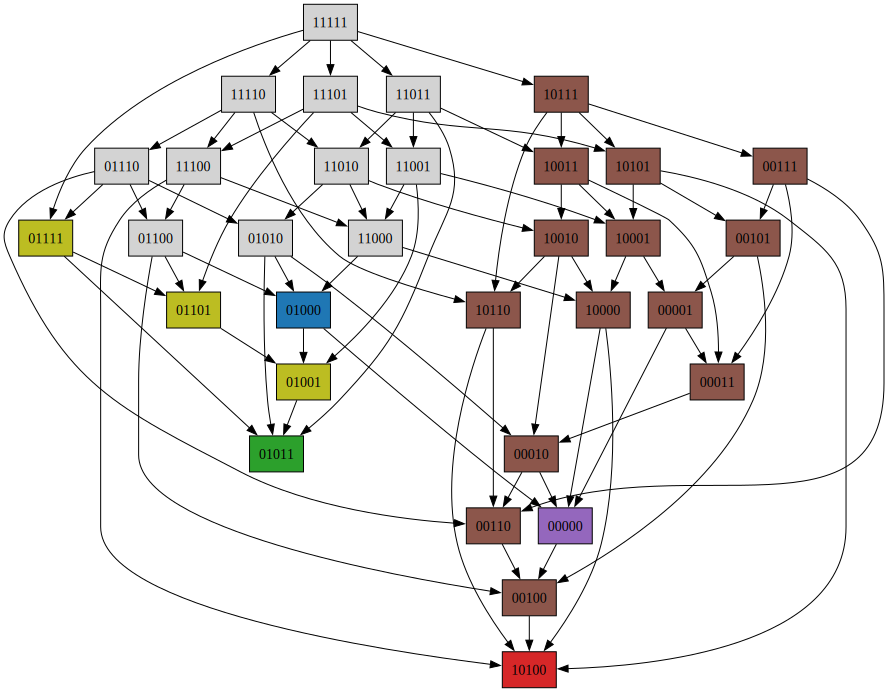

In [17]:
# For our small example, we can visualise the basins using the highlight functionality.
# Note that we are only showing the strong basins, because in this case, the remaining (not highlighted)
# nodes represent the intersection of the two weak basins (i.e., the grey nodes are in both weak basins,
# and in neither strong basin).

# If we had more than two fixed points, we may be interested in different combinations of weak basins as well
# (e.g., states that can reach `A` and `B`, but cannot reach `C`, etc.)

stg.show(
     highlight=[
         (colors['brown'],   posterior_strong_basin),
         (colors['olive'],   anterior_strong_basin),
         (colors['green'],   PHENOTYPES['anterior-late']),
         (colors['red'],     PHENOTYPES['posterior-late']),
         (colors['blue'],    PHENOTYPES['anterior-early']),
         (colors['purple'],  PHENOTYPES['posterior-early']),
    ],   
)

## "The problem"

In our original discussion of the model, we mentioned that there are also two "transient" phenotypes. These correspond to the initial developmental state before differentiation (where in the anterior region, `FGF8` expression has been activated by some external mechanism).

We can easily verify that each transient phenotype can evolve into the expected terminal phenotype (this is also apparent from the state transition graph above).

In [18]:
posterior_early = stg.mk_subspace(PHENOTYPES['posterior-early'])
anterior_early = stg.mk_subspace(PHENOTYPES['anterior-early'])

print("Posterior evolution:", posterior_early.is_subset(posterior_weak_basin))
print("Anterior evolution:", anterior_early.is_subset(anterior_weak_basin))

Posterior evolution: True
Anterior evolution: True


However, we can observe the following problem: While the early posterior phenotype can indeed evolve only into the late posterior phenotype, the early anterior phenotype can evolve into both: If the `FGF8` activity spontaneously collapses, the anterior and the posterior phenotypes evolve into the same terminal state.

In [19]:
print("Posterior to anterior evolution:", posterior_early.is_subset(anterior_weak_basin))
print("Anterior to posterior evolution:", anterior_early.is_subset(posterior_weak_basin))

# Alternatively, we could also use the strong basins to check the same property (think about how!)

Posterior to anterior evolution: False
Anterior to posterior evolution: True


Clearly, the model is capable of "self-sustaining" the `FGF8` activity under the right conditions. Otherwise we could not have the `anterior-late` fixed point. However, this self-sustainment is limited to a rather small portion of the state space which does not include the `anterior-early` state (we can also see that the strong basin of the anterior phenotype is much smaller than for the posterior phenotype in general).

**In the next tutorial, we will try to fix this by finding a Boolean network using the same regulatory graph, where this anterior-posterior separation is more strict, ensuring that the anterior phenotype cannot evolve into the posterior one.**

## Exercise:

1. Display the subspace of the STG where `FGF8` is active. Show a variant with and without outgoing transitions.

2. Think about the outgoing transition leaving the 'anterior-early' phenotype. Which of the genes changes its activity during that transition?


## Appendix: Complex attractors and network reduction

You may have noticed that in the STG of our model, there are no cycles: from every state, by following individual edges, I eventually reach a fixed point. While this is very practical, it is not universally true for all Boolean networks, and in some cases, cycles are in fact desirable (for representing oscillation or other "repeating but not constant" expression patterns).

If such a cycle (or a more complex collection of interlocking cycles) cannot be escaped (similar to a fixed point), we call such a set of states a *complex attractor*.

As before, we can compute the complex attractors of a Boolean network and visualize them (as long as they are small enough).

Let's open another small model from the [BBM database](https://bbm.sybila.fi.muni.cz) and have a look at such cyclic attractor in practice.

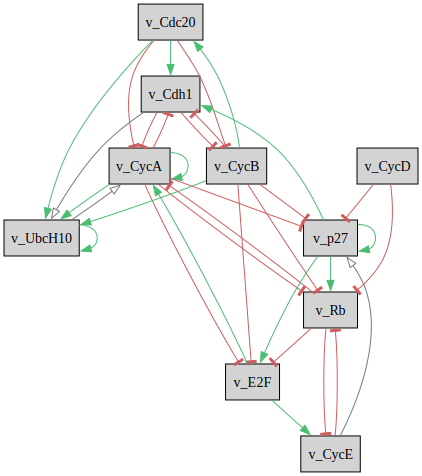

In [20]:
# Model name: MAMMALIAN-CELL-CYCLE-2006
# The model has one input variable (discussed below). 
# Here, while loading the model, we set the input variable to `true`.
bn = ba.BiodivineBooleanModels.fetch_model('023').to_bn_inputs_true()
bn.show()

This model has 10 variables, one of which is an input (`v_CycD`), meaning it has 1024 states. This is a bit too much for our visualization, but we can easily verify that there is indeed a large, complex attractor somewhere in the state space of this network:

In [21]:
stg = ba.AsynchronousGraph(bn)
for attractor in ba.Attractors.attractors(stg):
    print("Attractor states:", attractor.cardinality())

Attractor states: 112


While 112 states is not that much (you can try running `stg.show(subgraph=attractor)`; it will work and show you a graph), it is already somewhat incomprehensible to a normal person.

Consequently, to visualize this attractor (and ideally the whole state space), we will use something called *network reduction*. 

If we have a network variable `X` that does not regulate itself, we can take its update function and "inline" it into the update function of every other variable `Y` which is regulated by `X`. Then, we can remove `X` because its effect is now integrated into the update functions it was influencing previously.

This is not a completely "lossless" operation. First of all, in the result, we no longer have information about the variable we just eliminated. Furthermore, this operation can also eliminate complex attractors or turn them into fixed points (e.g., if the complex attractor only flips the value of the eliminated variable). Similarly, it can merge fixed points into one fixed point, for example, if the fixed points only differ in the value of the variable we just eliminated.

As such, it is good to further validate that the results of the reduction have not disrupted the phenotypes of our network "too much".

Remaining variables: 9
Remaining variables: 8
Remaining variables: 7
Remaining variables: 6
Remaining variables: 5
Remaining variables: 4
Attractor states: 16



Regulatory graph:


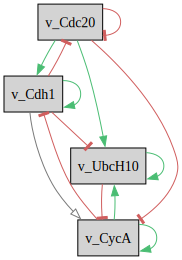

In [22]:
bn_reduced = bn
# First, we can eliminate the input variable. This variable always tends towards `True` and 
# therefore any state where it is `False` cannot be in any attractor.
bn_reduced = bn_reduced.inline_variable('v_CycD', repair_graph=True)
print("Remaining variables:", bn_reduced.variable_count())

# Next, we eliminate some of the other variables that don't have a self-regulation in order to
# make the network even smaller.
bn_reduced = bn_reduced.inline_variable('v_CycB', repair_graph=True)
print("Remaining variables:", bn_reduced.variable_count())
bn_reduced = bn_reduced.inline_variable('v_E2F', repair_graph=True)
print("Remaining variables:", bn_reduced.variable_count())
bn_reduced = bn_reduced.inline_variable('v_p27', repair_graph=True)
print("Remaining variables:", bn_reduced.variable_count())
bn_reduced = bn_reduced.inline_variable('v_Rb', repair_graph=True)
print("Remaining variables:", bn_reduced.variable_count())
bn_reduced = bn_reduced.inline_variable('v_CycE', repair_graph=True)
print("Remaining variables:", bn_reduced.variable_count())

# In the end, we validate that the complex 
stg = ba.AsynchronousGraph(bn_reduced)
for attractor in ba.Attractors.attractors(stg):
    print("Attractor states:", attractor.cardinality())

print("\n\n")
print("Regulatory graph:")
bn_reduced.show()

Notice that due to reductions we performed, the attractor is now the whole state space of the network. We reduced the state space from 1024 states to just 16, and the attractor size also shrunk from 112 states to 16. As such, the basin states are now lost due to the reduction (or rather, they are indistinguishable from the attractor states). However, we can finally draw the attractor graph easily:

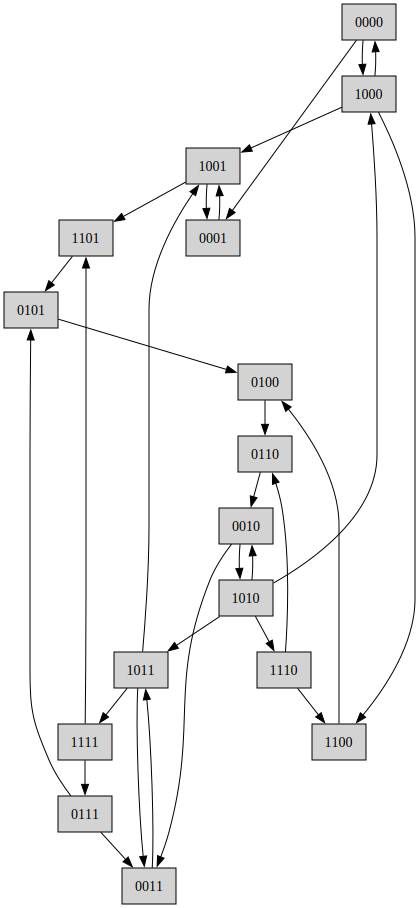

In [23]:
stg.show(subgraph=attractor)

As you can see, the graph is still somewhat complex. However, there is also clearly some structure in it. Looking at the [original paper](https://academic.oup.com/bioinformatics/article/22/14/e124/227890) where this model was introduced, we can see that the cyclic attractor represents different phases of a cell cycle. These phases are:

 - S-phase; synthesis,
 - M-phase; mitosis,
 - G1-phase and G2-phase; gap phases.

The cell cycle then proceeds as `G1 -> S -> G2 -> M -> G1 ...`. Furthermore, the phases can be sometimes broken up into smaller sub-phases (especially mitosis).

While the paper does not provide a complete mapping between network states and cell cycle phases, we can reconstruct the following assignment from the literature. Note that this assingment is somewhat oversimplified because we only have four variables available, but should be enough as a demonstration. 

If a variable is missing from the phenotype description, it means it can take any possible value, meaning the phenotype is "active" across more than one state (as seen in the graph below).

In [24]:
PHENOTYPES = {
    'G1'   : { 'v_Cdc20': 0, 'v_Cdh1': 1, 'v_CycA': 0                },   
    'S'    : { 'v_Cdc20': 0,              'v_CycA': 1, 'v_UbcH10': 0 },   
    'G2'   : { 'v_Cdc20': 0, 'v_Cdh1': 0, 'v_CycA': 1, 'v_UbcH10': 1 },   
    'M'    : { 'v_Cdc20': 1,                           'v_UbcH10': 1 },   
}

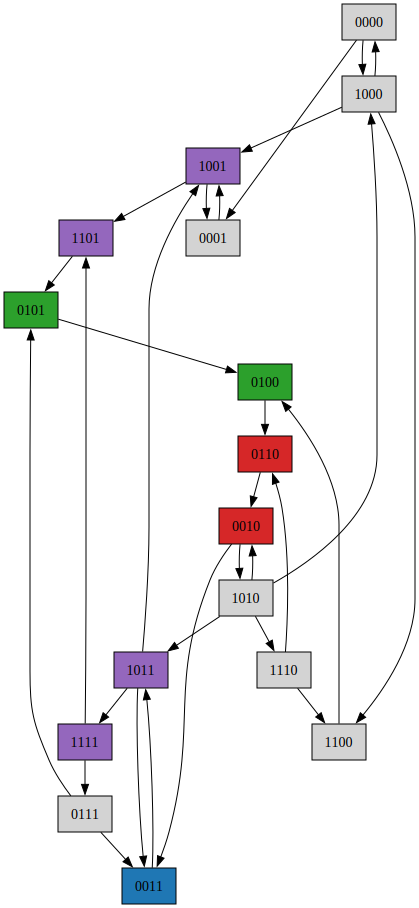

In [25]:
stg.show(
    subgraph=attractor,
    highlight=[
        (colors['green'],   PHENOTYPES['G1']),
        (colors['red'],     PHENOTYPES['S']),
        (colors['blue'],    PHENOTYPES['G2']),
        (colors['purple'],  PHENOTYPES['M']),
    ]
)

As we can see, the graph contains a lot of states that we cannot map to a specific cell cycle phase, and some of these even allow us to "skip" a particular phase. However, an important observation is that there is indeed a path representing the cell cycle transitions in the order in which they should be taken (`"green" -> "red" -> "blue" -> "purple"`).

This presence of "spurious transitions" is an unfortunate byproduct of the asynchronous update. The goal of asynchronous update is to include a transition every time it is at least theoretically possible in the underlying biological system. However, not all of these theoretical possibilities will be also realizable in practice. Consequently, we can sometimes observe spurious transitions. Furthermore, some of these spurious transitions could be introduced by our network reduction.

There are other techniques that try to eliminate such transitions, but these are beyond the scope of this tutorial.